# Aula 3 — Data Storytelling e Dashboards Web Interativos

**Ciência de Dados · 4º período · Bacharelado em Inteligência Artificial — IComp/UFAM**

## Objetivos

Ao final desta aula, você será capaz de:

1. Distinguir **análise exploratória** de **análise explanatória** e saber quando cada uma se aplica.
2. Estruturar uma **narrativa de dados** (contexto → conflito → resolução) e adaptá-la à audiência.
3. Aplicar **princípios de design de dashboards** para reduzir carga cognitiva.
4. Construir, do zero, um **dashboard web interativo** em Streamlit sobre um conjunto de dados **real**.

> **Fio condutor da aula.** Em vez de dados fictícios, vamos trabalhar o tempo todo com um recorte
> real do **Olist** — o maior marketplace do varejo brasileiro — com ~96 mil pedidos entregues
> entre 2016 e 2018. Cada conceito teórico será ancorado numa pergunta de negócio que esses dados
> respondem, e a Parte 2 transforma essas respostas num produto de dados navegável.


---


## Parte 1 — A arte de comunicar insights

### O problema: gráficos não são conclusões

Na aula anterior produzimos dezenas de visualizações para _explorar_ os dados. Mas um analista
raramente é avaliado pelos gráficos que gerou — e sim pela **decisão que ajudou a tomar**. A
comunicação é a _última milha_ da análise: a etapa em que a descoberta vira ação. Sem ela, o
trabalho técnico corre o risco de ser ignorado.

**Data storytelling** é a prática de comunicar descobertas usando **narrativa + visualização** para
contextualizar insights e inspirar ação. Não é enfeite: é a ponte entre o esforço analítico e o
impacto no negócio.

Um exemplo concreto com o nosso dataset. A tabela crua diz:

| entregue_no_prazo | avaliação média | nº de pedidos |
| :---------------- | --------------: | ------------: |
| Sim               |        **4,29** |        89.443 |
| Não               |        **2,27** |         6.381 |

O _storytelling_ transforma esses quatro números numa frase acionável:

> _"Quando um pedido atrasa, a nota do cliente despenca de 4,3 para 2,3 estrelas — uma queda de
> **dois pontos**. Reduzir atrasos não é só logística: é a nossa alavanca de satisfação nº 1."_

Repare que a segunda versão tem **contexto**, **comparação** e uma **recomendação implícita**. É
isso que uma tabela sozinha não entrega.


---


### Exploratória vs. explanatória: dois propósitos

Toda análise atravessa duas fases com objetivos opostos:

- **Exploratória** — você _procura_ a história. Vira "100 pedras para achar 1 ou 2 joias".
  Alta interatividade, muitos gráficos, público = você mesmo.
- **Explanatória** — você já _tem_ a joia e precisa _contá-la_. Poucos gráficos, ordenados numa
  sequência que conduz a audiência até a conclusão.

O erro clássico é apresentar o material exploratório (tudo o que você olhou) quando a audiência
precisa do explanatório (só o que importa). O diagrama abaixo resume o fluxo — a descoberta
**precede** a comunicação:


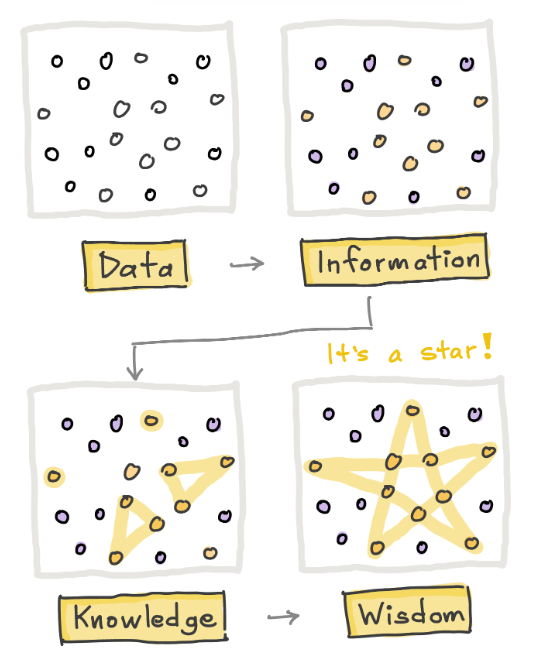


|                    | Exploratória                       | Explanatória                            |
| :----------------- | :--------------------------------- | :-------------------------------------- |
| **Propósito**      | Descobrir padrões e hipóteses      | Comunicar uma conclusão específica      |
| **Audiência**      | O próprio analista / time de dados | Stakeholders, gestores, clientes        |
| **Pergunta**       | "O que os dados me dizem?"         | "Qual a resposta para _esta_ pergunta?" |
| **Interatividade** | Alta (filtros, drill-down livre)   | Guiada pela narrativa                   |
| **Volume**         | Muitos gráficos                    | Seletivo — só as "joias"                |
| **Foco**           | Descoberta                         | Clareza, persuasão, ação                |

**Para quem constrói dashboards:** mesmo com filtros, um bom dashboard tem uma **intenção
explanatória** dominante. O filtro serve para o usuário _aprofundar a mesma história_ — não para
transformar a tela num despejo de dados sem direção.


### A estrutura de uma narrativa de dados

Uma boa história de dados segue a mesma arquitetura de qualquer boa história — **contexto, conflito,
resolução** — porque essa forma engaja o cérebro em compreensão, emoção e empatia ao mesmo tempo,
tornando o insight memorável e acionável (e não apenas _verdadeiro_).

Aplicando ao Olist, com os números reais que vamos calcular na Parte 2:

1. **Contexto (início).** _"A diretoria quer entender por que a satisfação do cliente estagnou em
   torno de 4,1 estrelas, apesar do crescimento de pedidos em 2017–2018."_

2. **Conflito / trama (meio).** _"Descobrimos que 93% das entregas chegam no prazo e recebem 4,3
   estrelas — mas os 7% que atrasam recebem apenas 2,3, e concentram-se no Norte e Nordeste, onde
   o frete chega a **28% do valor do pedido** e o prazo médio é o dobro do Sudeste."_

3. **Resolução / chamada para ação (fim).** _"Recomendamos priorizar a malha logística do Norte/
   Nordeste: cada ponto percentual de atraso evitado nessas regiões vale mais em satisfação do que
   qualquer campanha de marketing."_

> **Regra prática.** Um dashboard não é um repositório de dados — é uma ferramenta que conta _essa_
> história, com um fluxo lógico que leva do problema à recomendação.

**Exemplos reais de storytelling de produto:**

- **Spotify Wrapped** transforma dados de uso pessoal numa narrativa anual compartilhável — puro
  storytelling explanatório, individualizado em escala de milhões.
- **Nubank / iFood / Mercado Livre** publicam "retrospectivas" e relatórios de impacto que usam a
  mesma estrutura contexto→conflito→resolução para comunicar valor a clientes e ao mercado.


### Conhecendo a audiência: a mesma descoberta, três narrativas

A eficácia de uma história depende de adaptá-la a quem a consome. Usando **exatamente o mesmo
achado** do Olist (atraso derruba satisfação), veja como a ênfase muda:

- **Para o CEO** → foco estratégico e financeiro: _"Atrasos custam ~2 estrelas por pedido; em
  regiões de expansão isso trava o crescimento. ROI da melhoria logística supera o de aquisição."_
  Conciso, orientado à decisão, com KPIs de alto nível.

- **Para o gerente de operações/logística** → foco acionável: _"O atraso concentra-se em 6 estados
  do Norte/Nordeste; o prazo médio lá é 20–22 dias vs. 10 no Sudeste. Priorizar transportadoras
  nessas rotas."_ Segmentado e operacional.

- **Para o time de dados/engenharia** → foco técnico: qualidade dos dados de entrega, tratamento de
  `order_delivered_customer_date` nula, definição de "no prazo" (`atraso_dias <= 0`), performance da
  agregação. Detalhe e reprodutibilidade.

**Lição:** falhar em adaptar a mensagem faz a análise parecer irrelevante — ou, pior, quebra a
confiança. Um dashboard pode precisar de **camadas** (abas, filtros, níveis de detalhe) justamente
para servir públicos diferentes a partir da mesma base.


### Exercício teórico (10 min)

**Cenário.** Você é analista no Olist. Descobriu que a categoria **Cama, Mesa e Banho** é a campeã
em _volume_ de pedidos, mas tem ticket médio baixo e nota de avaliação abaixo da média geral —
enquanto **Informática e Acessórios** vende menos, porém com ticket alto e clientes mais satisfeitos.

**Tarefa.** Para uma audiência de **Gerentes de Categoria (Marketplace)**, estruture uma narrativa
de dados usando **contexto → conflito → resolução**:

- **Contexto:** qual é a pergunta de negócio?
- **Conflito (insights):** quais achados sustentam a história?
- **Resolução (ação):** qual recomendação clara e mensurável você propõe?

Guarde sua resposta — na Parte 2 você poderá _validar_ cada afirmação com o dashboard que vamos
construir.


---


## Dashboards web: o que são e como projetá-los

Um **dashboard** é uma interface visual que entrega, _de relance_, a informação necessária para
atingir um objetivo. A palavra-chave é _de relance_: se o usuário precisa estudar a tela para
entender, o dashboard falhou. Ele é uma **ferramenta de decisão**, não um exibidor de dados.


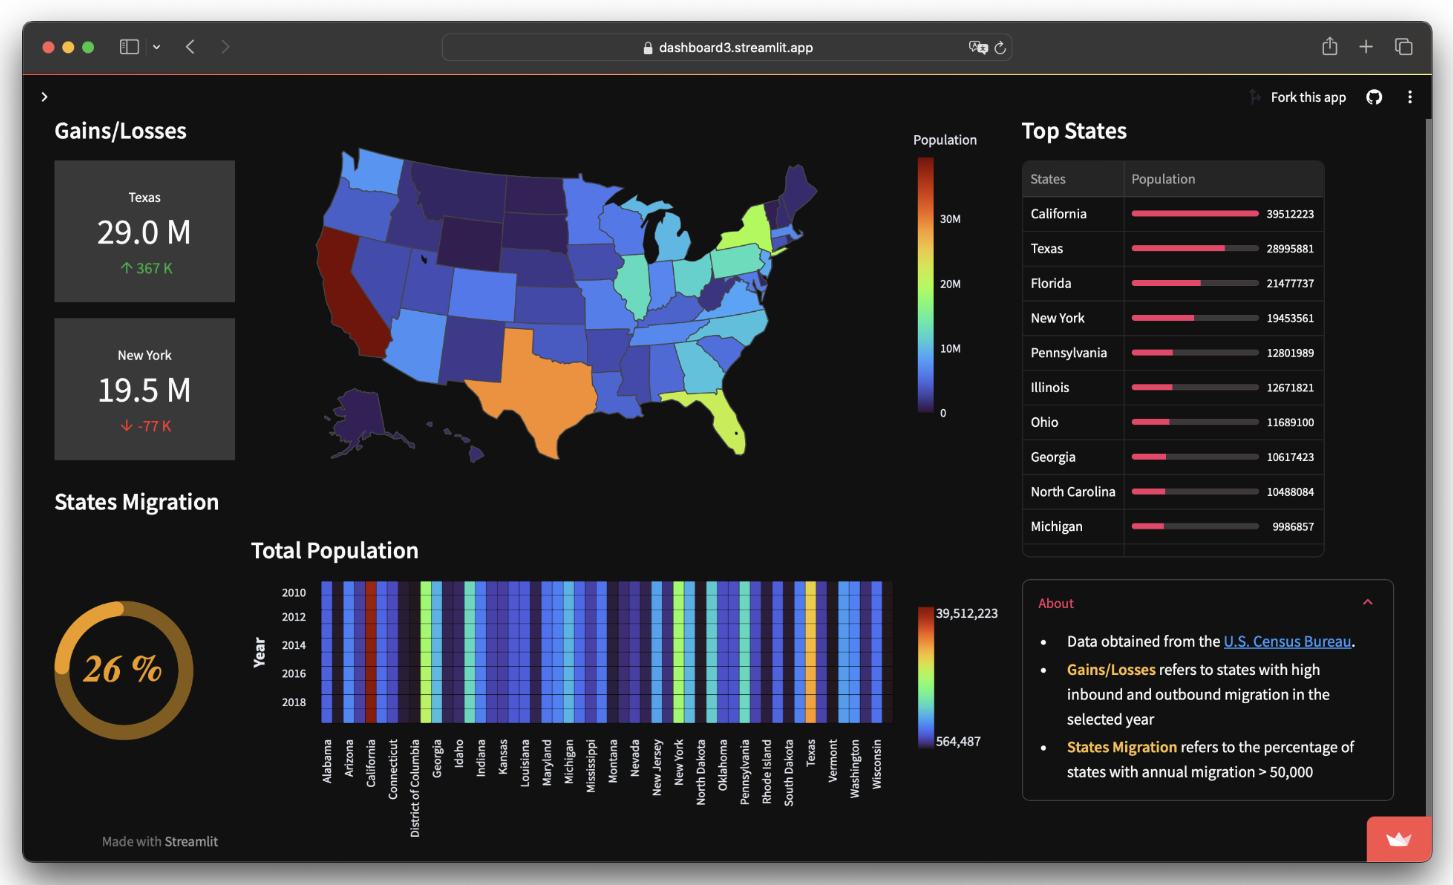


### Seis princípios de design (com o filtro do bom senso)

1. **Clareza e simplicidade** — _"menos é mais"_. Espaço em branco não é desperdício; é o que
   permite o conteúdo respirar.
2. **Hierarquia** — o KPI mais importante vai no **topo/esquerda** (lemos em Z). Tamanho, cor e
   posição guiam o olhar.
3. **Contexto é rei** — um número isolado não significa nada. _R$ 160 de ticket médio_ só vira
   insight ao lado de uma meta, de um período anterior ou de um benchmark. Por isso usaremos o
   parâmetro `delta` do `st.metric` com **variação real** (não simulada).
4. **Gráfico certo para a pergunta** — barra para comparar categorias; linha para tendência no
   tempo; _box/violin_ para distribuição; mapa/coroplético para geografia. Eixo Y de barras
   **sempre começa em zero**.
5. **Interatividade com propósito** — filtros e drill-down deixam o usuário aprofundar _a mesma
   história_, no seu ritmo.
6. **Consistência** — cores, fontes e rótulos uniformes reduzem o esforço de leitura.

O objetivo transversal a todos eles é **minimizar a carga cognitiva**. A tentação de "colocar tudo"
ou usar visuais chamativos deve ser resistida: simplicidade e intenção valem mais que complexidade.


### Erros comuns — e por que doem

Quase todo dashboard ruim comete a mesma troca: **prioriza estética sobre clareza**. Os sintomas:

- **Sobrecarga** — gráficos demais espremidos, sem foco.
- **Falta de contexto** — números sem comparação; impossível saber se "está bom".
- **Cores sem propósito** — arco-íris decorativo em vez de destaque intencional.
- **3D e enfeites** — pizza 3D distorce a percepção de área e atrapalha a comparação.
- **Rótulos ruins / não-responsivo** — ambiguidade e quebra em telas menores.

Compare os dois exemplos abaixo — um limpo, com KPIs claros e paleta contida; outro poluído, com
tipos de gráfico misturados e cores aleatórias. Ver o "certo vs. errado" fixa os princípios muito
mais do que uma lista de regras.


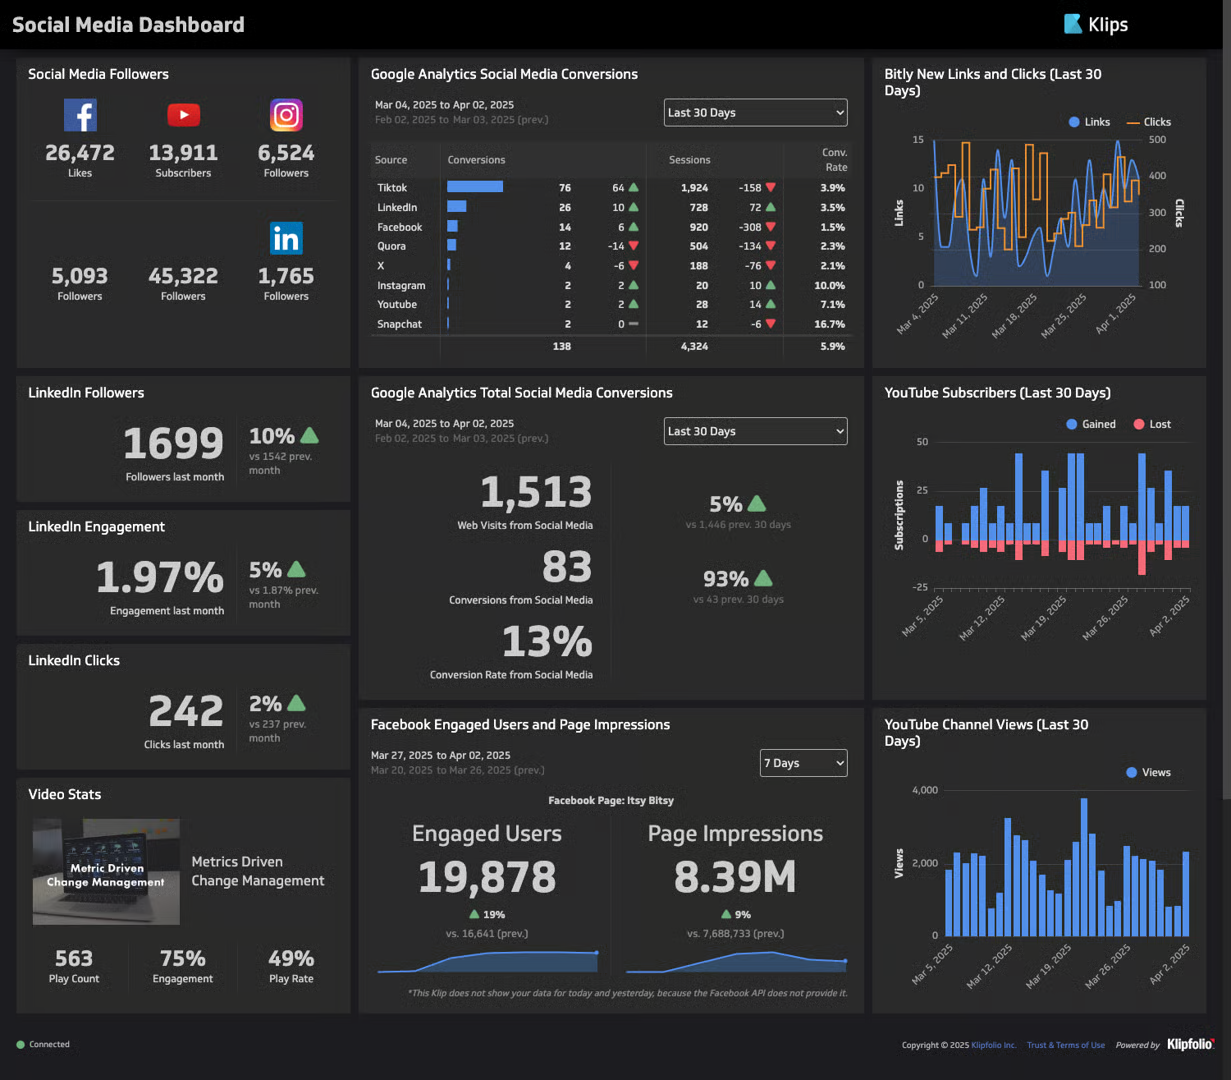


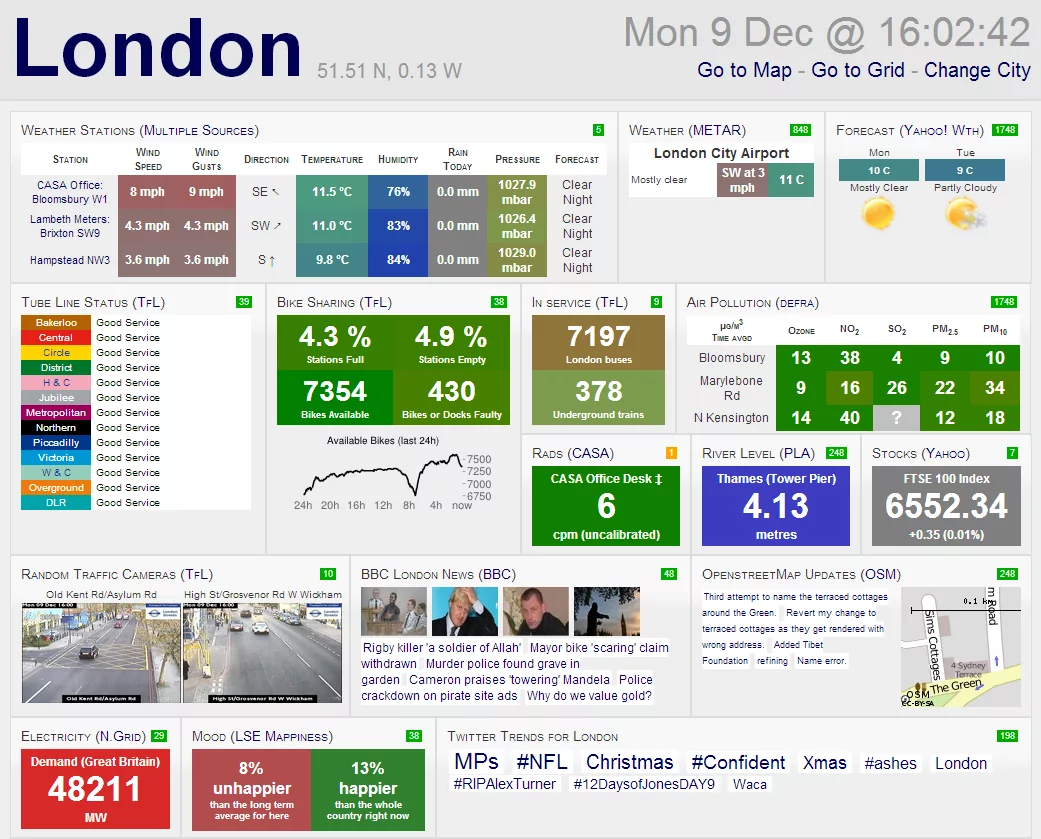


### Streamlit: a forma mais rápida de virar um script num app de dados

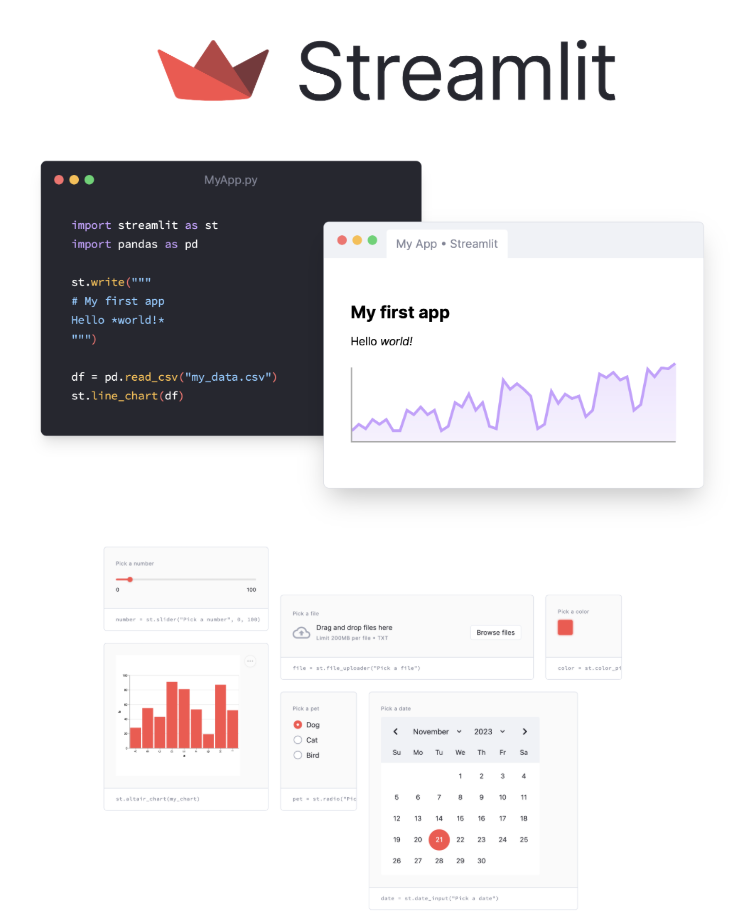


**Streamlit** é uma biblioteca Python open-source que transforma um script em um app web
interativo — sem HTML, CSS ou JavaScript. Por que ela domina o protótipo de produtos de dados:

- **Ciclo rápido:** você escreve Python puro, salva, e o app recarrega sozinho. Do conceito ao
  protótipo em minutos.
- **Configuração mínima:** nada de servidores, rotas ou _boilerplate_ de front-end.
- **Modelo reativo:** a cada interação com um _widget_, o **script inteiro roda de novo** de cima a
  baixo. Você nunca gerencia estado de DOM manualmente — só descreve _o que_ mostrar. (O custo disso
  é performance em bases grandes; a solução é `@st.cache_data`, que veremos e usaremos.)
- **Ecossistema Python:** pandas, Plotly, scikit-learn — tudo se encaixa nativamente.
- **Deploy simples:** _Streamlit Community Cloud_ hospeda apps públicos de graça a partir de um
  repositório GitHub.

Em resumo, Streamlit **democratiza** a criação de aplicações de dados: quem sabe Python vira capaz
de entregar um produto navegável, não só um notebook.


---


## Parte 2 — Construindo um dashboard real com dados do Olist

Agora saímos da teoria. Vamos construir, passo a passo, um dashboard que responde a perguntas de
negócio reais sobre o marketplace Olist:

- **Quanto** vendemos, com que **ticket médio** e que **satisfação** — e como isso variou no tempo?
- **Onde** estão nossos clientes e **quanto custa** entregar para cada região?
- O **atraso na entrega** realmente derruba a avaliação? Em quais regiões?

Cada seção primeiro _prototipa o gráfico aqui no notebook_ (para você ver o resultado na hora) e
depois mostra _o trecho equivalente do `app.py`_. Ao final, montamos o `app.py` completo.


### 1. Preparação do ambiente e dos dados

**Ambiente local** (no terminal, uma vez por projeto):

```bash
mkdir dashboard_olist && cd dashboard_olist
python -m venv venv
# Windows:  .\venv\Scripts\activate
# macOS/Linux:  source venv/bin/activate
pip install streamlit pandas plotly
```

Crie o arquivo `app.py` (ponto de entrada) e coloque o `olist_pedidos.csv` na mesma pasta.

#### O conjunto de dados: `olist_pedidos.csv`

Diferente de um dataset de brinquedo, este é um **recorte real e anonimizado** do Olist (dados
comerciais de verdade, disponibilizados publicamente). Cada linha é **um pedido entregue**. As
colunas:

| Coluna                                         | Descrição                                          |
| :--------------------------------------------- | :------------------------------------------------- |
| `id_pedido`                                    | Identificador do pedido                            |
| `data_pedido`                                  | Timestamp da compra                                |
| `estado`, `regiao`, `cidade`                   | Geografia do cliente (UF, macrorregião, município) |
| `categoria`                                    | Categoria do produto (rótulos em PT-BR)            |
| `qtd_itens`                                    | Nº de itens no pedido                              |
| `valor_produtos`, `valor_frete`, `valor_total` | Valores em R$                                      |
| `prazo_entrega_dias`                           | Dias entre compra e entrega                        |
| `atraso_dias`                                  | Dias além da data estimada (negativo = adiantado)  |
| `entregue_no_prazo`                            | `True` se `atraso_dias <= 0`                       |
| `avaliacao`                                    | Nota do cliente (1–5 estrelas)                     |
| `id_cliente`                                   | Cliente anonimizado (permite ver recompra)         |

Vamos carregar e conhecer os dados:


In [ ]:
import pandas as pd
import plotly.express as px

# Carregar dados reais. parse_dates converte a coluna de data já na leitura.
df = pd.read_csv('olist_pedidos.csv', parse_dates=['data_pedido'])

print(
    f"{len(df):,} pedidos  |  {df['data_pedido'].min():%b/%Y} a {df['data_pedido'].max():%b/%Y}")
print(f"{df['estado'].nunique()} estados  |  {df['categoria'].nunique()} categorias")
df.head()

96,470 pedidos  |  Sep/2016 a Aug/2018
27 estados  |  23 categorias


,id_pedido,data_pedido,estado,regiao,cidade,categoria,qtd_itens,valor_produtos,valor_frete,valor_total,prazo_entrega_dias,atraso_dias,entregue_no_prazo,avaliacao,id_cliente
0,bfbd0f9bdef84302105ad712db648a6c,2016-09-15 12:16:38,SP,Sudeste,sao joaquim da barra,Saúde e Beleza,3,134.97,8.49,143.46,54.0,36.0,False,1.0,830d5b7aaa3b6f1e9ad63703bec97d23
1,3b697a20d9e427646d92567910af6d57,2016-10-03 09:44:50,SP,Sudeste,sao paulo,Relógios e Presentes,1,29.90,15.56,45.46,23.0,-1.0,True,4.0,32ea3bdedab835c3aa6cb68ce66565ef
2,be5bc2f0da14d8071e2d45451ad119d9,2016-10-03 16:56:50,RS,Sul,panambi,Esporte e Lazer,1,21.90,17.19,39.09,24.0,-11.0,True,4.0,2f64e403852e6893ae37485d5fcacdaf
3,a41c8759fbe7aab36ea07e038b2d4465,2016-10-03 21:13:36,RS,Sul,porto alegre,Esporte e Lazer,1,36.49,17.24,53.73,30.0,-26.0,True,3.0,61db744d2f835035a5625b59350c6b63
4,d207cc272675637bfed0062edffd0818,2016-10-03 22:06:03,SP,Sudeste,hortolandia,Móveis e Decoração,1,119.90,13.56,133.46,27.0,-23.0,True,1.0,8d3a54507421dbd2ce0a1d58046826e0


In [3]:
# Um retrato rápido do negócio (as "manchetes" que viram KPIs)
print("Ticket médio:      R$ {:.2f}".format(df['valor_total'].mean()))
print("Avaliação média:   {:.2f} estrelas".format(df['avaliacao'].mean()))
print("Entregas no prazo: {:.1f}%".format(df['entregue_no_prazo'].mean()*100))
print("Frete médio:       R$ {:.2f} ({:.1f}% do valor)".format(
    df['valor_frete'].mean(), (df['valor_frete']/df['valor_total']).mean()*100))
df.describe(include='number').round(2)

Ticket médio:      R$ 159.83
Avaliação média:   4.16 estrelas
Entregas no prazo: 93.2%
Frete médio:       R$ 22.79 (20.9% do valor)


,qtd_itens,valor_produtos,valor_frete,valor_total,prazo_entrega_dias,atraso_dias,avaliacao
count,96470.00,96470.00,96470.00,96470.00,96470.00,96470.00,95824.00
mean,1.14,137.04,22.79,159.83,12.09,-11.88,4.16
std,0.54,209.05,21.56,218.80,9.55,10.18,1.28
min,1.00,0.85,0.00,9.59,0.00,-147.00,1.00
25%,1.00,45.90,13.85,61.85,6.00,-17.00,4.00
50%,1.00,86.50,17.17,105.28,10.00,-12.00,5.00
75%,1.00,149.90,24.02,176.26,15.00,-7.00,5.00
max,21.00,13440.00,1794.96,13664.08,209.00,188.00,5.00


### 2. Esqueleto do app e o _cache_ de dados

Todo app Streamlit começa com **configuração de página**, **título** e **carregamento de dados**.
Duas boas práticas que o tutorial anterior não trazia e que fazem diferença real:

- **`st.set_page_config(...)`** deve ser a **primeira** chamada Streamlit do script. Define título
  da aba, ícone e `layout="wide"` (essencial para dashboards).
- **`@st.cache_data`** memoriza o retorno da função de carga. Como o Streamlit reexecuta o script
  _inteiro_ a cada clique, sem cache o CSV seria relido a cada interação. Com cache, lê uma vez.

```python
# ===== app.py (início) =====
import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(
    page_title="Olist · Dashboard de Vendas",
    page_icon="📦",
    layout="wide",
)

@st.cache_data
def carregar_dados(caminho: str = "olist_pedidos.csv") -> pd.DataFrame:
    df = pd.read_csv(caminho, parse_dates=["data_pedido"])
    df["mes"] = df["data_pedido"].dt.to_period("M").dt.to_timestamp()
    return df

df = carregar_dados()

st.title("📦 Olist — Dashboard de Vendas e Logística")
st.caption("Marketplace brasileiro · pedidos entregues entre 2016 e 2018 · dados públicos anonimizados")
```

Rode com `streamlit run app.py`. O app abre em `http://localhost:8501` e recarrega a cada `Ctrl+S`.


### 3. Barra lateral: filtros que contam a _mesma_ história

Aqui está uma **lacuna importante** do tutorial original: ele filtrava só por estado. Um dashboard
de verdade combina filtros de **geografia**, **categoria** e **período**. O filtro de intervalo de
datas (`st.date_input` com dois valores) e o _slider_ são especialmente úteis e não apareciam antes.

Prototipamos a _lógica_ de filtragem aqui (sem widgets) e mostramos o código Streamlit logo depois:


In [ ]:
# Simulação da lógica de filtragem que os widgets vão alimentar no app.py
regioes_sel = ['Sudeste', 'Nordeste']        # viria de st.sidebar.multiselect
categorias_sel = df['categoria'].unique().tolist()  # todas
data_ini, data_fim = pd.Timestamp('2017-01-01'), pd.Timestamp('2018-08-31')

mask = (
    df['regiao'].isin(regioes_sel) &
    df['categoria'].isin(categorias_sel) &
    df['data_pedido'].between(data_ini, data_fim)
)
dff = df[mask]
print(f"Filtro aplicado: {len(dff):,} de {len(df):,} pedidos "
      f"({len(dff)/len(df)*100:.0f}%) — {', '.join(regioes_sel)}, "
      f"{data_ini:%b/%Y}–{data_fim:%b/%Y}")

**Trecho equivalente no `app.py`** — todos os widgets vivem em `st.sidebar`:

```python
st.sidebar.header("🔎 Filtros")

regioes = sorted(df["regiao"].dropna().unique())
regioes_sel = st.sidebar.multiselect("Região", regioes, default=regioes)

cats = sorted(df["categoria"].unique())
categorias_sel = st.sidebar.multiselect("Categoria", cats, default=cats)

# Filtro de PERÍODO (lacuna do tutorial antigo): date_input com dois valores
data_min, data_max = df["data_pedido"].min().date(), df["data_pedido"].max().date()
periodo = st.sidebar.date_input(
    "Período", value=(data_min, data_max),
    min_value=data_min, max_value=data_max,
)
# date_input pode devolver 1 data enquanto o usuário escolhe a 2ª — trate isso:
if isinstance(periodo, tuple) and len(periodo) == 2:
    data_ini, data_fim = pd.Timestamp(periodo[0]), pd.Timestamp(periodo[1])
else:
    data_ini, data_fim = pd.Timestamp(data_min), pd.Timestamp(data_max)

# Filtro numérico com slider (ticket mínimo)
ticket_min = st.sidebar.slider("Ticket mínimo (R$)", 0, 500, 0, step=10)

mask = (
    df["regiao"].isin(regioes_sel)
    & df["categoria"].isin(categorias_sel)
    & df["data_pedido"].between(data_ini, data_fim)
    & (df["valor_total"] >= ticket_min)
)
dff = df[mask]

if dff.empty:
    st.warning("Nenhum pedido corresponde aos filtros. Ajuste a seleção.")
    st.stop()
```

> **Detalhe que quebra apps em produção:** `st.date_input` com intervalo retorna **uma única data**
> no instante entre o usuário clicar na data inicial e na final. Se você desempacotar
> `ini, fim = periodo` cego, o app quebra. O `if isinstance(...)` acima trata esse estado.


### 4. KPIs com contexto: `st.metric` e _delta_ calculado de verdade

O tutorial antigo exibia `delta="Simulado: +10%"` — um placeholder. Isso viola o princípio
**"contexto é rei"**: o delta existe justamente para dar significado ao número. Vamos calcular a
variação **real** dos últimos 90 dias contra os 90 dias anteriores.


In [ ]:
def kpis_com_delta(dados: pd.DataFrame):
    """Retorna (valor_atual, delta_%) para os principais KPIs,
    comparando os últimos 90 dias com os 90 dias anteriores."""
    if dados.empty:
        return None
    fim = dados['data_pedido'].max()
    recente = dados[dados['data_pedido'] > fim - pd.Timedelta(days=90)]
    anterior = dados[(dados['data_pedido'] <= fim - pd.Timedelta(days=90)) &
                     (dados['data_pedido'] > fim - pd.Timedelta(days=180))]

    def var(col, agg='mean'):
        a = getattr(recente[col], agg)()
        b = getattr(anterior[col], agg)() if not anterior.empty else a
        return a, (0.0 if b == 0 else (a - b) / b * 100)

    ticket, d_ticket = var('valor_total', 'mean')
    nota,   d_nota = var('avaliacao', 'mean')
    return {
        'pedidos':  (len(dados), None),
        'ticket':   (ticket, d_ticket),
        'nota':     (nota, d_nota),
        'no_prazo': (dados['entregue_no_prazo'].mean()*100, None),
    }


k = kpis_com_delta(df)
for nome, (val, d) in k.items():
    print(f"{nome:10} = {val:,.2f}" +
          (f"   (Δ {d:+.1f}% vs. trimestre anterior)" if d is not None else ""))

**No `app.py`**, os KPIs vão lado a lado com `st.columns(4)`; o `delta` colore automaticamente
(verde ↑ / vermelho ↓):

```python
k = kpis_com_delta(dff)
c1, c2, c3, c4 = st.columns(4)
c1.metric("Pedidos", f"{k['pedidos'][0]:,}".replace(",", "."))
c2.metric("Ticket médio", f"R$ {k['ticket'][0]:,.2f}",
          delta=f"{k['ticket'][1]:+.1f}% vs. tri. anterior")
c3.metric("Avaliação média", f"{k['nota'][0]:.2f} ★",
          delta=f"{k['nota'][1]:+.1f}%")
c4.metric("Entregas no prazo", f"{k['no_prazo'][0]:.1f}%")
```


### 5. Gráficos organizados em **abas** (`st.tabs`)

Outra lacuna do tutorial original: tudo era empilhado verticalmente. Um dashboard real agrupa
visões por _pergunta_ usando **`st.tabs`** — "Visão Geral", "Geografia", "Logística". Cada aba conta
um capítulo da história. Vamos prototipar os gráficos de cada aba.

#### Aba 1 — Visão Geral: receita no tempo e mix de categorias


In [ ]:
# Série temporal mensal: pedidos e receita (dois eixos de leitura)
serie = (df.set_index('data_pedido')
           .resample('MS')
           .agg(pedidos=('id_pedido', 'count'), receita=('valor_total', 'sum'))
           .reset_index())

fig_tempo = px.area(
    serie, x='data_pedido', y='receita',
    title='Receita mensal (R$)', markers=True,
    labels={'data_pedido': 'Mês', 'receita': 'Receita (R$)'},
)
fig_tempo.update_traces(line_color='#2E86AB',
                        fillcolor='rgba(46,134,171,0.15)')
fig_tempo.show()

In [ ]:
# Mix de categorias por receita — barra horizontal ordenada (Top 10)
cat = (df.groupby('categoria')['valor_total'].sum()
         .sort_values(ascending=True).tail(10).reset_index())

fig_cat = px.bar(
    cat, x='valor_total', y='categoria', orientation='h',
    title='Top 10 categorias por receita',
    labels={'valor_total': 'Receita (R$)', 'categoria': ''},
    color='valor_total', color_continuous_scale='Blues',
)
fig_cat.update_layout(coloraxis_showscale=False)
fig_cat.show()

#### Aba 2 — Geografia: onde estão os clientes e o dinheiro


In [ ]:
# Agregação por estado + mapa coroplético do Brasil (GeoJSON oficial do IBGE via plotly)
por_uf = (df.groupby('estado')
            .agg(pedidos=('id_pedido', 'count'),
                 receita=('valor_total', 'sum'),
                 ticket=('valor_total', 'mean'))
            .reset_index())

# GeoJSON das UFs (arquivo público comumente usado em exemplos de coroplético do Brasil)
GEOJSON_UF = ("https://raw.githubusercontent.com/codeforgermany/click_that_hood/"
              "main/public/data/brazil-states.geojson")

fig_mapa = px.choropleth(
    por_uf, geojson=GEOJSON_UF, locations='estado',
    featureidkey='properties.sigla', color='pedidos',
    color_continuous_scale='Blues', scope='south america',
    title='Pedidos por estado', labels={'pedidos': 'Pedidos'},
)
fig_mapa.update_geos(fitbounds='locations', visible=False)
fig_mapa.show()

> **Nota de robustez.** O `choropleth` acima depende de um GeoJSON externo. Em sala/offline, um
> **gráfico de barras por UF** conta a mesma história geográfica sem dependência de rede — e é o
> _fallback_ que colocaremos no `app.py` (dentro de um `try/except`), demonstrando uma prática real
> de engenharia: nunca deixar o dashboard quebrar por causa de um recurso externo.


In [ ]:
# Fallback geográfico robusto: barras por UF (sempre funciona, sem rede)
fig_uf = px.bar(
    por_uf.sort_values('pedidos', ascending=False),
    x='estado', y='pedidos', title='Pedidos por estado (UF)',
    labels={'estado': 'UF', 'pedidos': 'Pedidos'},
    color='ticket', color_continuous_scale='Teal',
    hover_data={'receita': ':.0f', 'ticket': ':.2f'},
)
fig_uf.show()
print("SP concentra {:.0f}% de todos os pedidos.".format(
    df['estado'].value_counts(normalize=True)['SP']*100))

#### Aba 3 — Logística: o atraso derruba a satisfação?

Este é o **insight-âncora** da nossa narrativa. Vamos prová-lo visualmente.


In [ ]:
# Distribuição da avaliação por status de entrega (a "joia" da análise)
fig_sat = px.box(
    df, x='entregue_no_prazo', y='avaliacao',
    title='Avaliação do cliente × entrega no prazo',
    labels={'entregue_no_prazo': 'Entregue no prazo?',
            'avaliacao': 'Nota (1–5)'},
    color='entregue_no_prazo',
    color_discrete_map={True: '#2E86AB', False: '#E15554'},
    category_orders={'entregue_no_prazo': [True, False]},
)
fig_sat.update_layout(showlegend=False)
fig_sat.show()

comp = df.groupby('entregue_no_prazo')['avaliacao'].mean()
print("No prazo: {:.2f} ★   |   Atrasado: {:.2f} ★   |   Queda: {:.2f} estrelas".format(
    comp[True], comp[False], comp[True]-comp[False]))

In [ ]:
# Custo logístico por região: frete como % do valor + prazo médio
reg = (df.assign(frete_pct=lambda d: d['valor_frete']/d['valor_total']*100)
         .groupby('regiao')
         .agg(frete_pct=('frete_pct', 'mean'),
              prazo=('prazo_entrega_dias', 'mean'),
              pedidos=('id_pedido', 'count'))
         .reset_index())

fig_reg = px.scatter(
    reg, x='prazo', y='frete_pct', size='pedidos', color='regiao',
    text='regiao', size_max=60,
    title='Custo e prazo de entrega por região',
    labels={'prazo': 'Prazo médio de entrega (dias)',
            'frete_pct': 'Frete (% do valor do pedido)'},
)
fig_reg.update_traces(textposition='top center')
fig_reg.show()

### 6. O `app.py` completo

Reunindo tudo: configuração, cache, filtros combinados (região + categoria + período + ticket),
KPIs com delta real, gráficos em abas, um `st.expander` com os dados brutos e um
**`st.download_button`** para o usuário exportar o recorte filtrado — duas funcionalidades úteis que
o tutorial original não cobria.

Copie o bloco abaixo para o seu `app.py`:


In [ ]:
# =====================================================================
# app.py — Dashboard Olist (Streamlit + Pandas + Plotly)
# Execute com:  streamlit run app.py
# =====================================================================
import streamlit as st
import pandas as pd
import plotly.express as px

# 1) Configuração da página — PRIMEIRA chamada Streamlit
st.set_page_config(page_title="Olist · Dashboard de Vendas",
                   page_icon="📦", layout="wide")

# 2) Carga de dados com cache (lê o CSV uma única vez)


@st.cache_data
def carregar_dados(caminho: str = "olist_pedidos.csv") -> pd.DataFrame:
    df = pd.read_csv(caminho, parse_dates=["data_pedido"])
    df["mes"] = df["data_pedido"].dt.to_period("M").dt.to_timestamp()
    return df


@st.cache_data
def para_download(dados: pd.DataFrame) -> bytes:
    return dados.to_csv(index=False).encode("utf-8")


try:
    df = carregar_dados()
except FileNotFoundError:
    st.error("Arquivo 'olist_pedidos.csv' não encontrado na pasta do app.")
    st.stop()

st.title("📦 Olist — Dashboard de Vendas e Logística")
st.caption(
    "Marketplace brasileiro · pedidos entregues 2016–2018 · dados públicos anonimizados")

# 3) Sidebar — filtros combinados
st.sidebar.header("🔎 Filtros")
regioes = sorted(df["regiao"].dropna().unique())
regioes_sel = st.sidebar.multiselect("Região", regioes, default=regioes)

cats = sorted(df["categoria"].unique())
categorias_sel = st.sidebar.multiselect("Categoria", cats, default=cats)

data_min, data_max = df["data_pedido"].min(
).date(), df["data_pedido"].max().date()
periodo = st.sidebar.date_input("Período", value=(data_min, data_max),
                                min_value=data_min, max_value=data_max)
if isinstance(periodo, tuple) and len(periodo) == 2:
    data_ini, data_fim = pd.Timestamp(periodo[0]), pd.Timestamp(periodo[1])
else:
    data_ini, data_fim = pd.Timestamp(data_min), pd.Timestamp(data_max)

ticket_min = st.sidebar.slider("Ticket mínimo (R$)", 0, 500, 0, step=10)

mask = (df["regiao"].isin(regioes_sel)
        & df["categoria"].isin(categorias_sel)
        & df["data_pedido"].between(data_ini, data_fim)
        & (df["valor_total"] >= ticket_min))
dff = df[mask]

if dff.empty:
    st.warning("Nenhum pedido corresponde aos filtros. Ajuste a seleção.")
    st.stop()

# 4) KPIs com delta real (últimos 90d vs. 90d anteriores)


def kpis_com_delta(dados):
    fim = dados["data_pedido"].max()
    rec = dados[dados["data_pedido"] > fim - pd.Timedelta(days=90)]
    ant = dados[(dados["data_pedido"] <= fim - pd.Timedelta(days=90)) &
                (dados["data_pedido"] > fim - pd.Timedelta(days=180))]

    def var(col):
        a = rec[col].mean()
        b = ant[col].mean() if not ant.empty else a
        return a, (0.0 if pd.isna(b) or b == 0 else (a - b) / b * 100)
    ticket, d_t = var("valor_total")
    nota,   d_n = var("avaliacao")
    return len(dados), ticket, d_t, nota, d_n, dados["entregue_no_prazo"].mean()*100


n, ticket, d_t, nota, d_n, prazo = kpis_com_delta(dff)
c1, c2, c3, c4 = st.columns(4)
c1.metric("Pedidos", f"{n:,}".replace(",", "."))
c2.metric("Ticket médio", f"R$ {ticket:,.2f}",
          delta=f"{d_t:+.1f}% vs. tri. ant.")
c3.metric("Avaliação média", f"{nota:.2f} ★", delta=f"{d_n:+.1f}%")
c4.metric("Entregas no prazo", f"{prazo:.1f}%")

st.divider()

# 5) Gráficos em abas
aba_geral, aba_geo, aba_log = st.tabs(
    ["📈 Visão Geral", "🗺️ Geografia", "🚚 Logística"])

with aba_geral:
    col1, col2 = st.columns([0.55, 0.45])
    serie = (dff.set_index("data_pedido").resample("MS")
                .agg(receita=("valor_total", "sum")).reset_index())
    fig_t = px.area(serie, x="data_pedido", y="receita", markers=True,
                    title="Receita mensal (R$)",
                    labels={"data_pedido": "Mês", "receita": "Receita (R$)"})
    fig_t.update_traces(line_color="#2E86AB",
                        fillcolor="rgba(46,134,171,0.15)")
    col1.plotly_chart(fig_t, use_container_width=True)

    cat = (dff.groupby("categoria")["valor_total"].sum()
              .sort_values().tail(10).reset_index())
    fig_c = px.bar(cat, x="valor_total", y="categoria", orientation="h",
                   title="Top 10 categorias por receita", color="valor_total",
                   color_continuous_scale="Blues",
                   labels={"valor_total": "Receita (R$)", "categoria": ""})
    fig_c.update_layout(coloraxis_showscale=False)
    col2.plotly_chart(fig_c, use_container_width=True)

with aba_geo:
    por_uf = (dff.groupby("estado")
                 .agg(pedidos=("id_pedido", "count"),
                      receita=("valor_total", "sum"),
                      ticket=("valor_total", "mean")).reset_index())
    GEO = ("https://raw.githubusercontent.com/codeforgermany/click_that_hood/"
           "main/public/data/brazil-states.geojson")
    try:  # coroplético; cai para barras se a rede falhar
        fig_m = px.choropleth(por_uf, geojson=GEO, locations="estado",
                              featureidkey="properties.sigla", color="pedidos",
                              color_continuous_scale="Blues", scope="south america",
                              title="Pedidos por estado")
        fig_m.update_geos(fitbounds="locations", visible=False)
        st.plotly_chart(fig_m, use_container_width=True)
    except Exception:
        fig_m = px.bar(por_uf.sort_values("pedidos", ascending=False),
                       x="estado", y="pedidos", color="ticket",
                       color_continuous_scale="Teal", title="Pedidos por estado (UF)")
        st.plotly_chart(fig_m, use_container_width=True)

with aba_log:
    col1, col2 = st.columns(2)
    fig_s = px.box(dff, x="entregue_no_prazo", y="avaliacao",
                   color="entregue_no_prazo",
                   color_discrete_map={True: "#2E86AB", False: "#E15554"},
                   category_orders={"entregue_no_prazo": [True, False]},
                   title="Avaliação × entrega no prazo",
                   labels={"entregue_no_prazo": "No prazo?", "avaliacao": "Nota"})
    fig_s.update_layout(showlegend=False)
    col1.plotly_chart(fig_s, use_container_width=True)

    reg = (dff.assign(frete_pct=lambda d: d["valor_frete"]/d["valor_total"]*100)
              .groupby("regiao")
              .agg(frete_pct=("frete_pct", "mean"),
                   prazo=("prazo_entrega_dias", "mean"),
                   pedidos=("id_pedido", "count")).reset_index())
    fig_r = px.scatter(reg, x="prazo", y="frete_pct", size="pedidos",
                       color="regiao", text="regiao", size_max=60,
                       title="Custo e prazo por região",
                       labels={"prazo": "Prazo médio (dias)",
                               "frete_pct": "Frete (% do valor)"})
    fig_r.update_traces(textposition="top center")
    col2.plotly_chart(fig_r, use_container_width=True)

st.divider()

# 6) Dados brutos (expander) + exportação do recorte filtrado
with st.expander("🔬 Ver dados filtrados / exportar"):
    st.dataframe(dff.head(200), use_container_width=True)
    st.download_button(
        "⬇️ Baixar CSV filtrado", data=para_download(dff),
        file_name="olist_filtrado.csv", mime="text/csv",
        icon=":material/download:",
    )

### 7. Boas práticas de layout que aplicamos

- **`layout="wide"`** aproveita a tela — dashboards sufocam na largura padrão.
- **`st.columns([0.55, 0.45])`** cria proporção intencional (não só 50/50); regra prática: não
  aninhar colunas mais de um nível.
- **`st.divider()`** separa blocos visualmente sem poluir (melhor que `"---"` em markdown).
- **`st.tabs`** agrupa por pergunta e reduz rolagem — cada aba é um capítulo da narrativa.
- **KPIs no topo** com `delta` real seguem a leitura em Z e o princípio "contexto é rei".

> Um bom exercício: aplique um **tema** próprio criando `.streamlit/config.toml` com
> `[theme] primaryColor="#2E86AB"` etc. — isso dá identidade visual consistente sem tocar no código.

> **Compatibilidade de versão.** Usamos `use_container_width=True` (padrão amplamente documentado).
> Em versões recentes do Streamlit ele foi substituído por `width="stretch"` — se o seu Streamlit
> emitir um aviso de depreciação, basta trocar `use_container_width=True` por `width="stretch"`. O
> comportamento é o mesmo.


---


## Conclusão e próximos passos

Construímos, sobre **dados reais do Olist**, um dashboard que não apenas exibe números — ele **conta
uma história**: o crescimento no tempo, a concentração geográfica no Sudeste, e o insight-âncora de
que **atrasos derrubam a satisfação em ~2 estrelas**, com custo logístico desproporcional no Norte/
Nordeste. Traduzimos a teoria (exploratória→explanatória, contexto→conflito→resolução, princípios de
design) num produto navegável.

**O que este dashboard faz:**

- Carrega dados reais com `@st.cache_data` (performático).
- Filtra por **região, categoria, período e ticket** — combinados.
- Exibe **KPIs com variação real** (não simulada).
- Organiza gráficos em **abas** temáticas com Plotly interativo.
- Oferece **exportação** do recorte filtrado e um mapa coroplético com _fallback_ robusto.

**Publicação (deploy).** Para compartilhar:

- **Streamlit Community Cloud** — o caminho mais rápido e gratuito. Suba `app.py`,
  `olist_pedidos.csv` e um `requirements.txt` (`streamlit`, `pandas`, `plotly`) num repositório
  **público** no GitHub e conecte em share.streamlit.io. Deploy em minutos.
- **Docker** — para controle total do ambiente, um `Dockerfile` com `EXPOSE 8501` e
  `CMD ["streamlit","run","app.py"]` roda em qualquer servidor.

**Desafios para praticar:**

1. Adicione uma aba **"Recompra"** usando `id_cliente` — que % de clientes compra mais de uma vez?
2. Troque o _delta_ dos KPIs para comparar **o recorte filtrado vs. a base inteira**.
3. Use `st.session_state` para um botão **"Limpar filtros"** que reseta todos os widgets.
4. Explore `@st.cache_data(ttl=...)` e meça o ganho de performance com `st.spinner`.
